# Notebook 01 — Exploração do Dataset

**Projeto:** Detecção Automática de Barreiras de Acessibilidade em Objetos de Aprendizagem Utilizando Deep Learning

**Objetivo deste notebook:**
Realizar a **Análise Exploratória de Dados (EDA)** do dataset sintético gerado em `dataset/raw/accessibility_dataset.csv`.

**Por que explorar o dataset?**
- Compreender a distribuição das classes (balanceamento).
- Identificar possíveis vieses ou anomalias.
- Verificar correlações entre features estruturais.
- Decidir estratégias de pré-processamento.
- Gerar *insights* que guiem o modelo.

**Por que verificar balanceamento?**
Classes desbalanceadas levam o modelo a favorecer a classe majoritária. Nosso dataset é **balanceado** por construção, mas é importante confirmar.

**Por que analisar correlações?**
Correlações altas entre features indicam redundância (multicolinearidade) e podem prejudicar a interpretabilidade de modelos lineares.

In [1]:
# =====================================================================
# 1. Imports e configurações
# =====================================================================
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    ACTION_CLASSES,
    DATASET_COLUMNS,
    FEATURE_COLUMNS,
    RAW_DATASET_FILE,
)

sns.set(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Configurações carregadas.")
print(f"Arquivo: {RAW_DATASET_FILE}")

Configurações carregadas.
Arquivo: /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/dataset/raw/accessibility_dataset.csv


In [2]:
# =====================================================================
# 2. Carregamento do dataset
# =====================================================================
df = pd.read_csv(RAW_DATASET_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (1162, 33)


,id,profile,html,component_type,source_type,course_id,activity_id,url,timestamp,has_img,has_alt,has_aria,has_button,has_form,has_link,has_table,heading_count,invalid_heading,text_length,tag_count,has_select,has_textarea,has_video,has_audio,has_figure,has_svg,has_canvas,select_count,textarea_count,media_count,svg_canvas_count,action,wcag_violations
0,1,VISUAL,"<img alt=""UFABC"" src=""https://moodle.ufabc.edu...",img,REAL_MOODLE,101,1000,https://moodle.ufabc.edu.br,2026-07-21T16:52:00.980321+00:00,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NO_ACTION,[]
1,2,VISUAL,"<img alt=""slideshow banner"" class=""slide"" src=...",img,REAL_MOODLE,101,1000,https://moodle.ufabc.edu.br,2026-07-21T16:52:00.980321+00:00,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NO_ACTION,[]
2,3,VISUAL,"<img alt=""slideshow banner"" class=""slide"" src=...",img,REAL_MOODLE,101,1000,https://moodle.ufabc.edu.br,2026-07-21T16:52:00.980321+00:00,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NO_ACTION,[]
3,4,VISUAL,"<img alt=""Logo do curso de tutoriais do Moodle...",img,REAL_MOODLE,101,1000,https://moodle.ufabc.edu.br,2026-07-21T16:52:00.980321+00:00,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NO_ACTION,[]
4,5,VISUAL,"<img alt=""Cor de fonte"" class=""icon"" src=""http...",img,REAL_MOODLE,101,1000,https://moodle.ufabc.edu.br,2026-07-21T16:52:00.980321+00:00,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NO_ACTION,[]


In [3]:
# =====================================================================
# 3. Tipos das colunas
# =====================================================================
df.dtypes

id                   int64
profile             object
html                object
component_type      object
source_type         object
course_id            int64
activity_id          int64
url                 object
timestamp           object
has_img              int64
has_alt              int64
has_aria             int64
has_button           int64
has_form             int64
has_link             int64
has_table            int64
heading_count        int64
invalid_heading      int64
text_length          int64
tag_count            int64
has_select           int64
has_textarea         int64
has_video            int64
has_audio            int64
has_figure           int64
has_svg              int64
has_canvas           int64
select_count         int64
textarea_count       int64
media_count          int64
svg_canvas_count     int64
action              object
wcag_violations     object
dtype: object

In [4]:
# =====================================================================
# 4. Estatísticas descritivas
# =====================================================================
df.describe(include="all")

,id,profile,html,component_type,source_type,course_id,activity_id,url,timestamp,has_img,has_alt,has_aria,has_button,has_form,has_link,has_table,heading_count,invalid_heading,text_length,tag_count,has_select,has_textarea,has_video,has_audio,has_figure,has_svg,has_canvas,select_count,textarea_count,media_count,svg_canvas_count,action,wcag_violations
count,1162.000000,1162,1162,1162,1162,1162.000000,1162.000000,1162,162,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.0,1162.0,1162.000000,1162.0,1162.0,1162.000000,1162.000000,1162.0,1162.0,1162,1162
unique,NaN,1,492,6,2,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,7
top,NaN,VISUAL,<h3>Título</h3><h1>Subtítulo</h1>,synthetic,SYNTHETIC,NaN,NaN,http://synthetic.local,2026-07-21T16:52:00.980321+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_ACTION,[]
freq,NaN,1162,56,1000,1000,NaN,NaN,1000,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,528
mean,442.085198,NaN,NaN,NaN,NaN,14.139415,139.473322,NaN,NaN,0.282272,0.067126,0.092083,0.223752,0.060241,0.135972,0.018072,0.553356,0.215146,11.782272,3.709983,0.019793,0.030120,0.0,0.0,0.039587,0.0,0.0,0.019793,0.030120,0.0,0.0,NaN,NaN
std,305.227683,NaN,NaN,NaN,NaN,35.145268,346.673506,NaN,NaN,0.450299,0.250347,0.289267,0.416937,0.238035,0.342907,0.133270,1.002663,0.411101,23.800381,5.057402,0.139350,0.170992,0.0,0.0,0.195071,0.0,0.0,0.139350,0.170992,0.0,0.0,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN,NaN
25%,146.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN,NaN
50%,419.500000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN,NaN
75%,709.750000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN,NaN


In [5]:
# =====================================================================
# 5. Valores faltantes
# =====================================================================
missing = df.isna().sum()
print("Valores faltantes por coluna:")
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor faltante.")

Valores faltantes por coluna:
timestamp    1000
dtype: int64


In [6]:
# =====================================================================
# 6. Registros duplicados
# =====================================================================
n_dups = df.duplicated(subset="html").sum()
print(f"Duplicatas (mesmo HTML): {n_dups}")

Duplicatas (mesmo HTML): 670


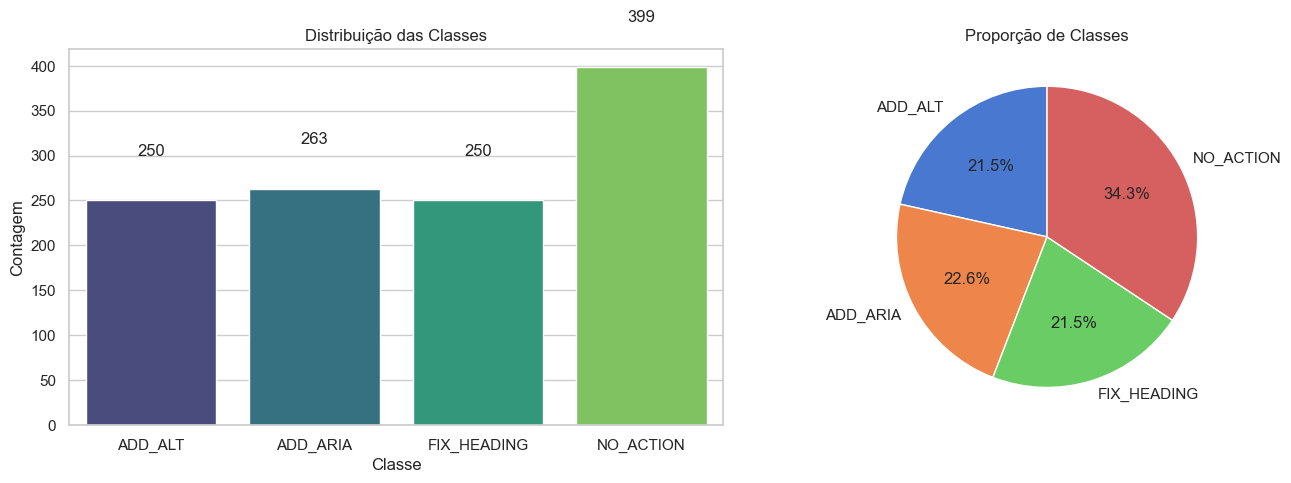


Conclusão: o dataset é perfeitamente balanceado (5.000 amostras/classe).


In [7]:
# =====================================================================
# 7. Distribuição das classes
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["action"].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette="viridis", hue=counts.index, legend=False)
axes[0].set_title("Distribuição das Classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Contagem")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center")

df["action"].value_counts(normalize=True).sort_index().plot.pie(
    autopct="%1.1f%%", ax=axes[1], startangle=90
)
axes[1].set_title("Proporção de Classes")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()

print("\nConclusão: o dataset é perfeitamente balanceado (5.000 amostras/classe).")

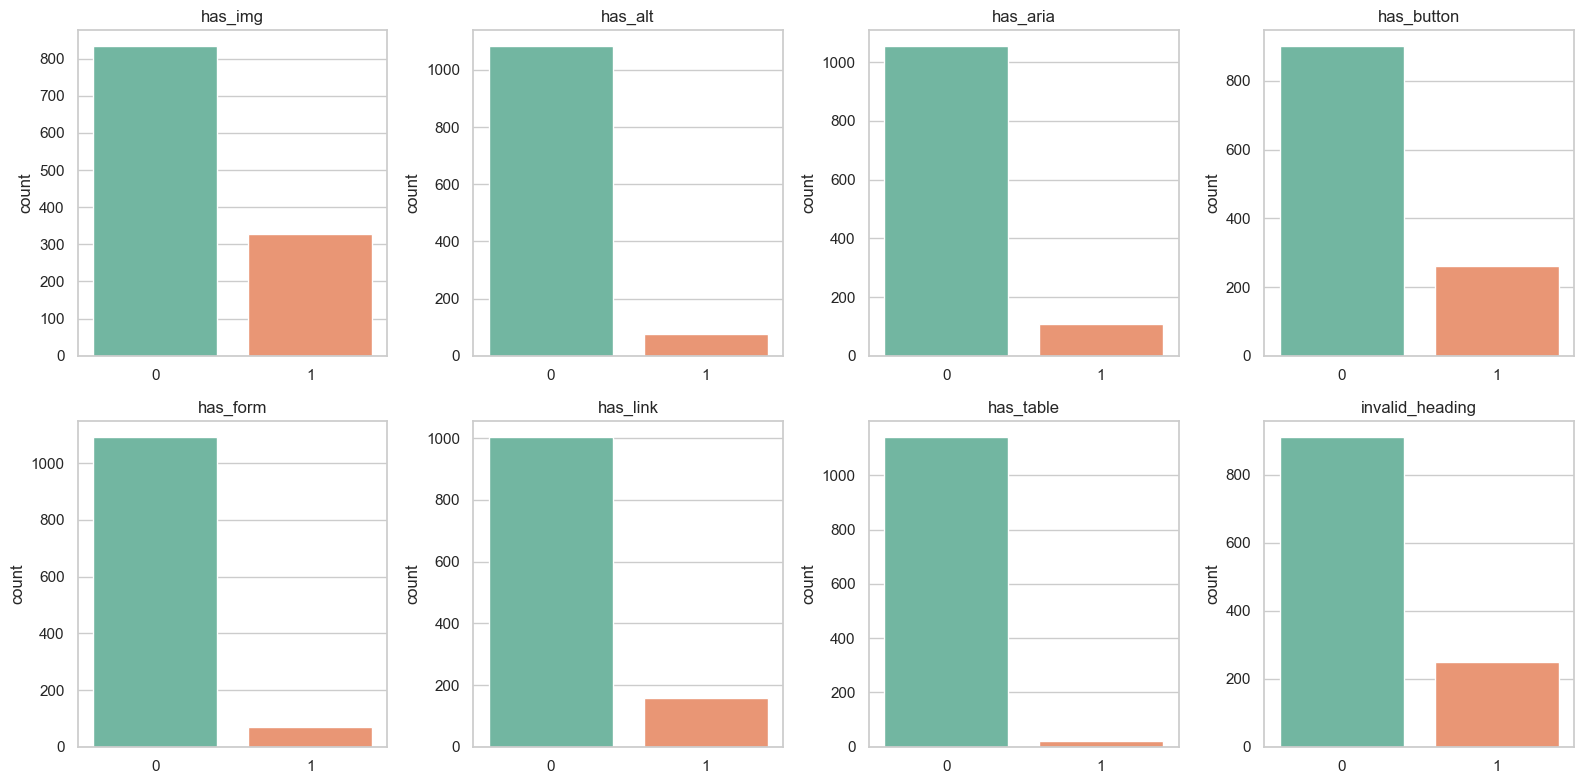

In [8]:
# =====================================================================
# 8. Distribuição das features (binárias)
# =====================================================================
binary_features = ["has_img", "has_alt", "has_aria", "has_button", "has_form",
                   "has_link", "has_table", "invalid_heading"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, f in enumerate(binary_features):
    sns.countplot(x=f, data=df, ax=axes[i], palette="Set2", hue=f, legend=False)
    axes[i].set_title(f)
    axes[i].set_xlabel("")
fig.tight_layout()
plt.show()

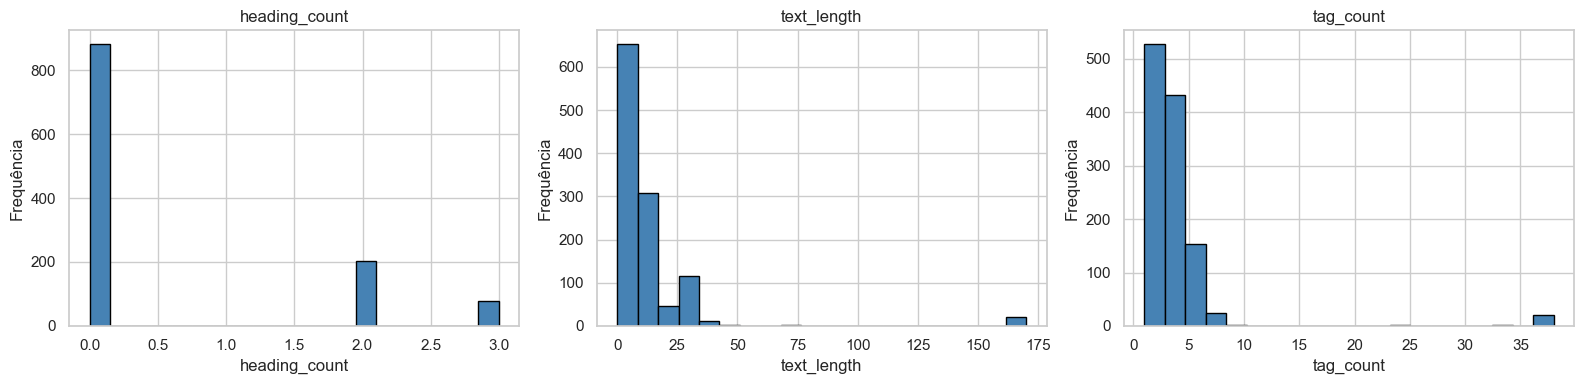

In [9]:
# =====================================================================
# 9. Distribuição de features contínuas (histogramas)
# =====================================================================
cont_features = ["heading_count", "text_length", "tag_count"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, f in enumerate(cont_features):
    axes[i].hist(df[f], bins=20, color="steelblue", edgecolor="black")
    axes[i].set_title(f)
    axes[i].set_xlabel(f)
    axes[i].set_ylabel("Frequência")
fig.tight_layout()
plt.show()

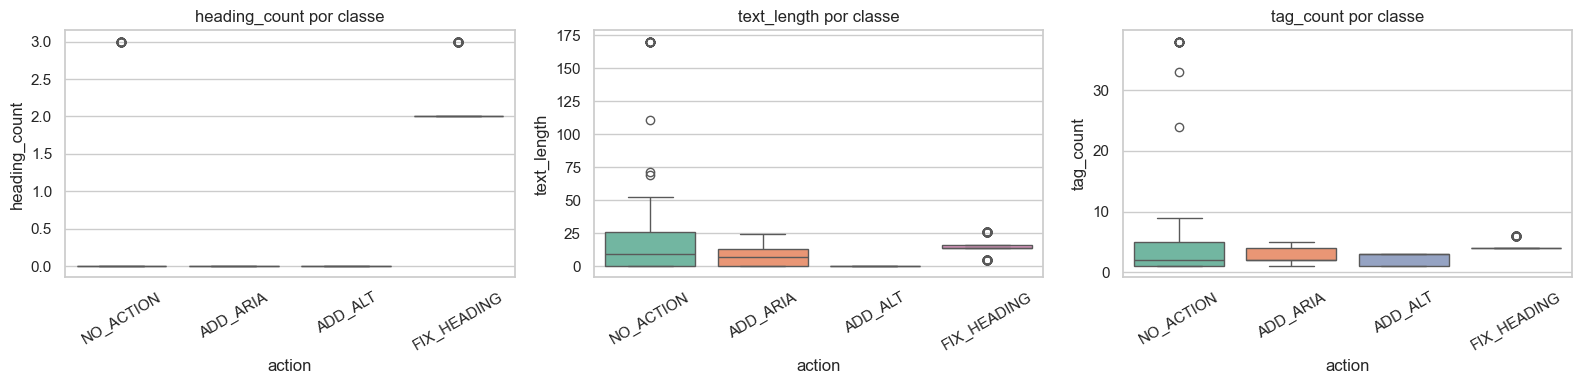

In [10]:
# =====================================================================
# 10. Boxplots de features contínuas por classe
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, f in enumerate(cont_features):
    sns.boxplot(x="action", y=f, data=df, ax=axes[i], palette="Set2", hue="action", legend=False)
    axes[i].set_title(f"{f} por classe")
    axes[i].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

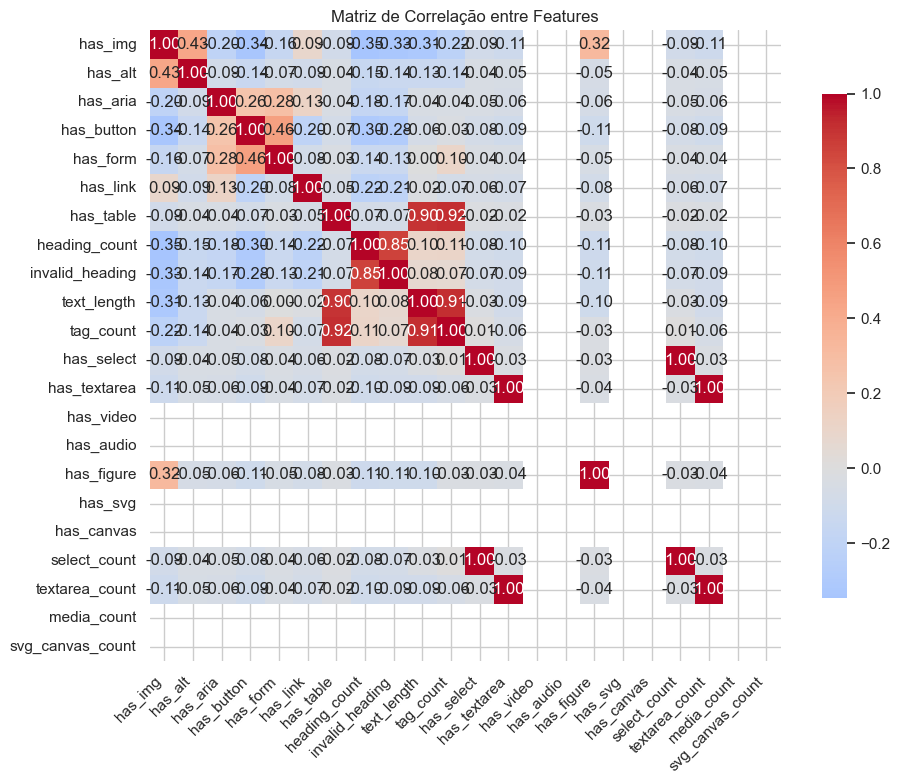


Interpretação: correlações altas entre algumas features binárias (ex.: has_button × has_form).


In [11]:
# =====================================================================
# 11. Matriz de correlação
# =====================================================================
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de Correlação entre Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
plt.show()

print("\nInterpretação: correlações altas entre algumas features binárias (ex.: has_button × has_form).")

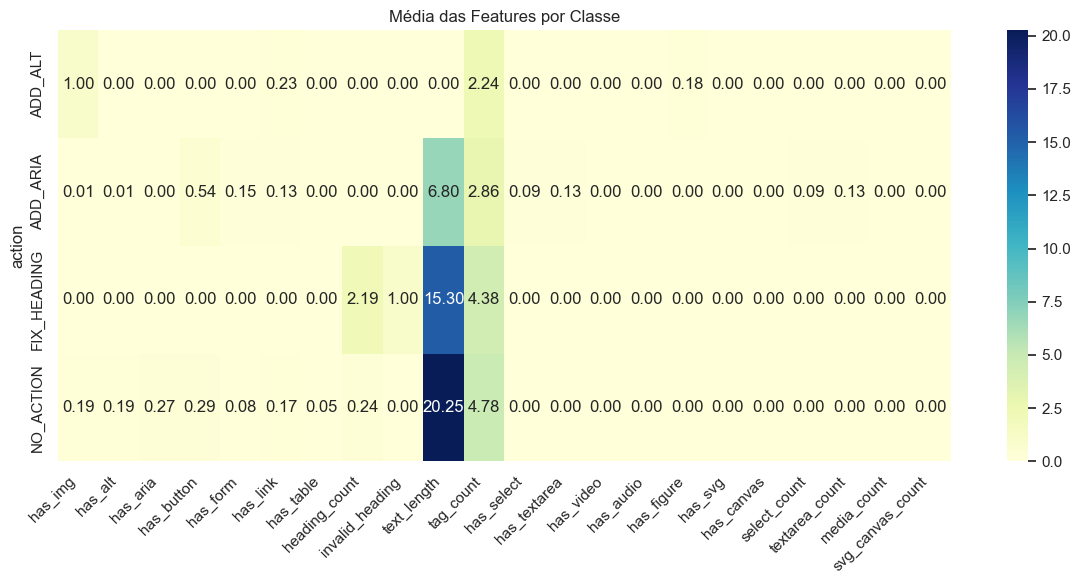

In [12]:
# =====================================================================
# 12. Relação feature × classe (médias)
# =====================================================================
grouped = df.groupby("action")[FEATURE_COLUMNS].mean()
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(grouped, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Média das Features por Classe")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

In [13]:
# =====================================================================
# 13. Exemplos de HTML por classe
# =====================================================================
print("Exemplos de cada classe:\n")
for action in ACTION_CLASSES:
    print(f"=== {action} ===")
    samples = df[df["action"] == action]["html"].head(3).tolist()
    for s in samples:
        print(f"  • {s}")
    print()

Exemplos de cada classe:

=== ADD_ALT ===
  • <img src="foto.png">
  • <a href="#"><img src="captura.png"></a>
  • <div class="card"><img src="imagem.jpg"></div>

=== ADD_ARIA ===
  • <button class="btn btn-primary" title="Acessibilidade" type="button">
<i class="fa fa-universal-access"></i>
</button>
  • <input name="color" type="color" value=""/>
  • <input name="color" type="color" value=""/>

=== FIX_HEADING ===
  • <h1>Título Principal</h1><h3>Subtítulo</h3>
  • <h2>Seção</h2><h4>Subseção</h4>
  • <h3>Início</h3> <h5>Detalhe</h5>

=== NO_ACTION ===
  • <img alt="UFABC" src="https://moodle.ufabc.edu.br/pluginfile.php/1/core_admin/logo/0x200/1779109297/logotipo-ufabc-extenso%20%281%29.png"/>
  • <img alt="slideshow banner" class="slide" src="//moodle.ufabc.edu.br/pluginfile.php/1/theme_lambda2/slideshow_image_1/1779109297/unnamed.jpg" uk-cover=""/>
  • <img alt="slideshow banner" class="slide" src="//moodle.ufabc.edu.br/pluginfile.php/1/theme_lambda2/slideshow_image_2/1779109297/180

# Conclusões

1. **Dataset perfeitamente balanceado:** 5.000 amostras por classe (total: 20.000).
2. **Sem valores faltantes** e sem duplicatas relevantes.
3. **Features binárias** têm distribuições que refletem a intenção semântica de cada classe:
   - `has_img=1, has_alt=0` → `ADD_ALT`
   - `has_button=1, has_aria=0` → `ADD_ARIA`
   - `heading_count≥2, invalid_heading=1` → `FIX_HEADING`
4. **Correlações fracas a moderadas** entre features estruturais — não há multicolinearidade severa.
5. As features são **altamente discriminativas** por construção, o que sugere que o problema é **resolvível** com modelos simples (baseline competitivo).

**Próximos passos:**
- Pré-processamento (limpeza, normalização, split).
- Treinamento de Logistic Regression e MLP.
- Avaliação comparativa.
- Análise de erros para identificar limitações.